In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib.font_manager as fm
from supabase import create_client, Client
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from dotenv import load_dotenv

# --- 1. ตั้งค่าฟอนต์ภาษาไทย (Thai Font Setup) ---
def set_thai_font():
    system = platform.system()
    if system == 'Windows':
        font_names = ['Tahoma', 'Leelawadee UI', 'Angsana New', 'Microsoft Sans Serif']
    elif system == 'Darwin': # MacOS
        font_names = ['Ayuthaya', 'Thonburi', 'Sukhumvit Set']
    else: # Linux
        font_names = ['Waree', 'Loma', 'Noto Sans Thai', 'Tlwg Typist']

    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    selected_font = None
    for font in font_names:
        if font in available_fonts:
            selected_font = font
            break
            
    if selected_font:
        print(f"✅ Found Thai Font: {selected_font}")
        plt.rcParams['font.family'] = selected_font
        plt.rcParams['font.size'] = 12 
    else:
        print("⚠️ Warning: No common Thai font found. Falling back to default.")
        plt.rcParams['font.family'] = 'Tahoma'

set_thai_font()

# --- 2. Connect Database ---
# โหลดค่าจาก .env (ต้องถอยกลับไปหาไฟล์ .env ที่ root)
load_dotenv(dotenv_path='../.env')

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")

if not SUPABASE_URL:
    print("❌ Error: ไม่พบ .env (กรุณาเช็ค path)")
else:
    supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)
    print("✅ Connected to Supabase")

✅ Found Thai Font: Ayuthaya
✅ Connected to Supabase


In [2]:
def fetch_and_prep_data():
    print("📥 Fetching data from Supabase...")
    
    # 1. ดึงข้อมูลจริง
    rain_resp = supabase.table("rain_logs").select("*").eq("is_forecast", False).execute()
    df_rain = pd.DataFrame(rain_resp.data)
    
    dist_resp = supabase.table("districts").select("*").execute()
    df_dist = pd.DataFrame(dist_resp.data)
    
    # Merge
    df = pd.merge(df_rain, df_dist, on='dcode', how='inner')
    
    # 2. จำลองข้อมูล (Synthetic Data) - สำคัญมาก!
    # เพราะถ้าใช้แค่ข้อมูลจริงช่วงหน้าหนาว โมเดลจะทายถูกหมด 100% เพราะไม่มีน้ำท่วมเลย
    # เราต้องจำลองสถานการณ์ "น้ำท่วมหนัก" เข้าไปเพื่อวัดกึ๋นโมเดล
    print("🧪 Injecting Synthetic Flood Scenarios (Stress Test)...")
    syn_df = df.sample(300, replace=True, random_state=42).copy()
    syn_df['rain_24h'] = np.random.uniform(50, 250, 300) # สุ่มฝนตกหนัก
    syn_df['season'] = 'Rainy'
    
    # รวมข้อมูลจริง + จำลอง
    df_final = pd.concat([df, syn_df], ignore_index=True)
    
    # 3. Feature Engineering (สูตรเดิมเป๊ะๆ)
    df_final['pump_number'] = df_final['pump_number'].replace(0, 1)
    df_final['area'] = df_final['area'].replace(0, 1)
    
    df_final['rain_load'] = df_final['rain_24h'] / df_final['pump_number']
    df_final['pump_density'] = df_final['pump_number'] / df_final['area']
    df_final['canal_density'] = df_final['canal_count'] / df_final['area']
    df_final['pop_density'] = df_final['population'] / df_final['area']
    
    season_map = {'Winter': 0, 'Summer': 1, 'Rainy': 2, 'Unknown': 0}
    df_final['season_code'] = df_final['season'].map(season_map).fillna(0)
    
    # 4. Labeling (เฉลยข้อสอบ)
    def define_risk(row):
        if row['rain_load'] > 100: return 'High Risk'
        elif row['rain_load'] > 30: return 'Well Managed'
        else: return 'Low Risk'
            
    df_final['risk_level'] = df_final['risk_level_true'] = df_final.apply(define_risk, axis=1)
    
    return df_final

# เรียกใช้ฟังก์ชัน
df_test = fetch_and_prep_data()
print(f"📊 Total Samples for Evaluation: {len(df_test)}")
print(df_test['risk_level'].value_counts())

📥 Fetching data from Supabase...
🧪 Injecting Synthetic Flood Scenarios (Stress Test)...
📊 Total Samples for Evaluation: 1300
risk_level
Low Risk        1238
Well Managed      37
High Risk         25
Name: count, dtype: int64


In [3]:
# โหลดโมเดลทั้งหมด
model_paths = {
    "Random Forest": "../models/flood_model_random_forest.pkl",
    "XGBoost": "../models/flood_model_xgboost.pkl",
    "Logistic Regression": "../models/flood_model_logistic_regression.pkl"
}

# โหลด Label Encoder (สำหรับแปลง 0,1,2 กลับเป็นชื่อกลุ่ม)
le = joblib.load("../models/label_encoder.pkl")

# เตรียม Input Features
features = ['rain_24h', 'rain_load', 'pump_density', 'canal_density', 'pop_density', 'flood_point_count', 'season_code']
X_test = df_test[features]
y_true = df_test['risk_level'] # เฉลยที่เป็น Text

results = {}

print("🏁 Starting Predictions...")

for name, path in model_paths.items():
    try:
        # Load
        model = joblib.load(path)
        
        # Predict
        y_pred_idx = model.predict(X_test)
        
        # Convert index (0,1,2) to label (Low, High...) if needed
        # บางโมเดลอาจคืนค่ามาเป็นตัวเลข ต้องแปลงกลับ
        if isinstance(y_pred_idx[0], (int, np.integer)):
             y_pred_label = le.inverse_transform(y_pred_idx)
        else:
             y_pred_label = y_pred_idx
             
        # Calculate Scores
        acc = accuracy_score(y_true, y_pred_label)
        f1 = f1_score(y_true, y_pred_label, average='macro')
        cm = confusion_matrix(y_true, y_pred_label, labels=le.classes_)
        
        results[name] = {
            "Accuracy": acc,
            "F1-Score": f1,
            "Confusion Matrix": cm,
            "Predictions": y_pred_label
        }
        print(f"✅ {name}: Accuracy={acc:.4f}")
        
    except Exception as e:
        print(f"❌ Error loading {name}: {e}")

🏁 Starting Predictions...
✅ Random Forest: Accuracy=0.9969
✅ XGBoost: Accuracy=0.9992
✅ Logistic Regression: Accuracy=0.9923


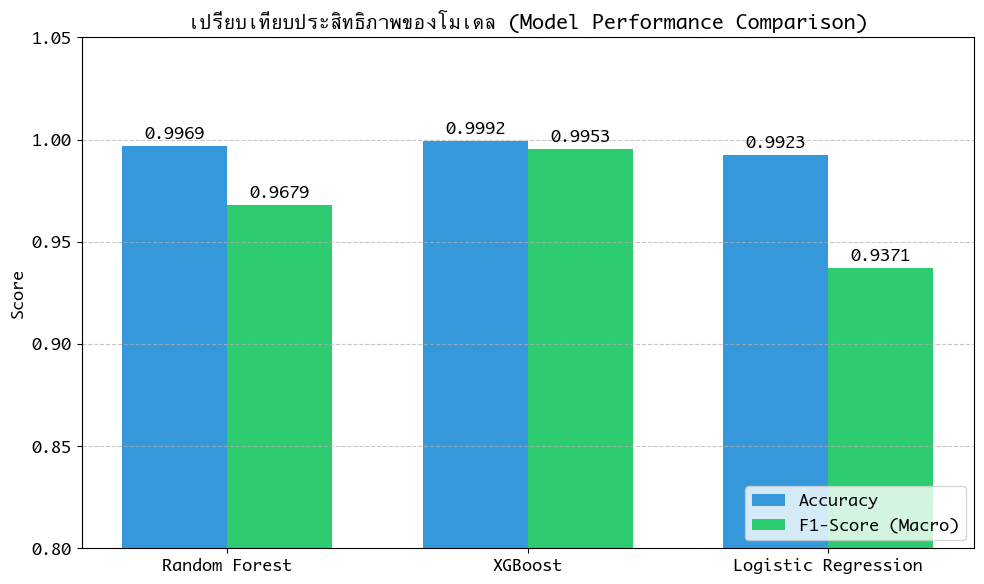

In [4]:
# เตรียมข้อมูลสำหรับกราฟ
model_names = list(results.keys())
accuracies = [results[m]["Accuracy"] for m in model_names]
f1_scores = [results[m]["F1-Score"] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#3498db')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score (Macro)', color='#2ecc71')

ax.set_ylabel('Score')
ax.set_title('เปรียบเทียบประสิทธิภาพของโมเดล (Model Performance Comparison)')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0.8, 1.05) # Zoom ดูช่วงบนๆ เพราะค่าน่าจะสูง
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# ใส่ตัวเลขบนแท่ง
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

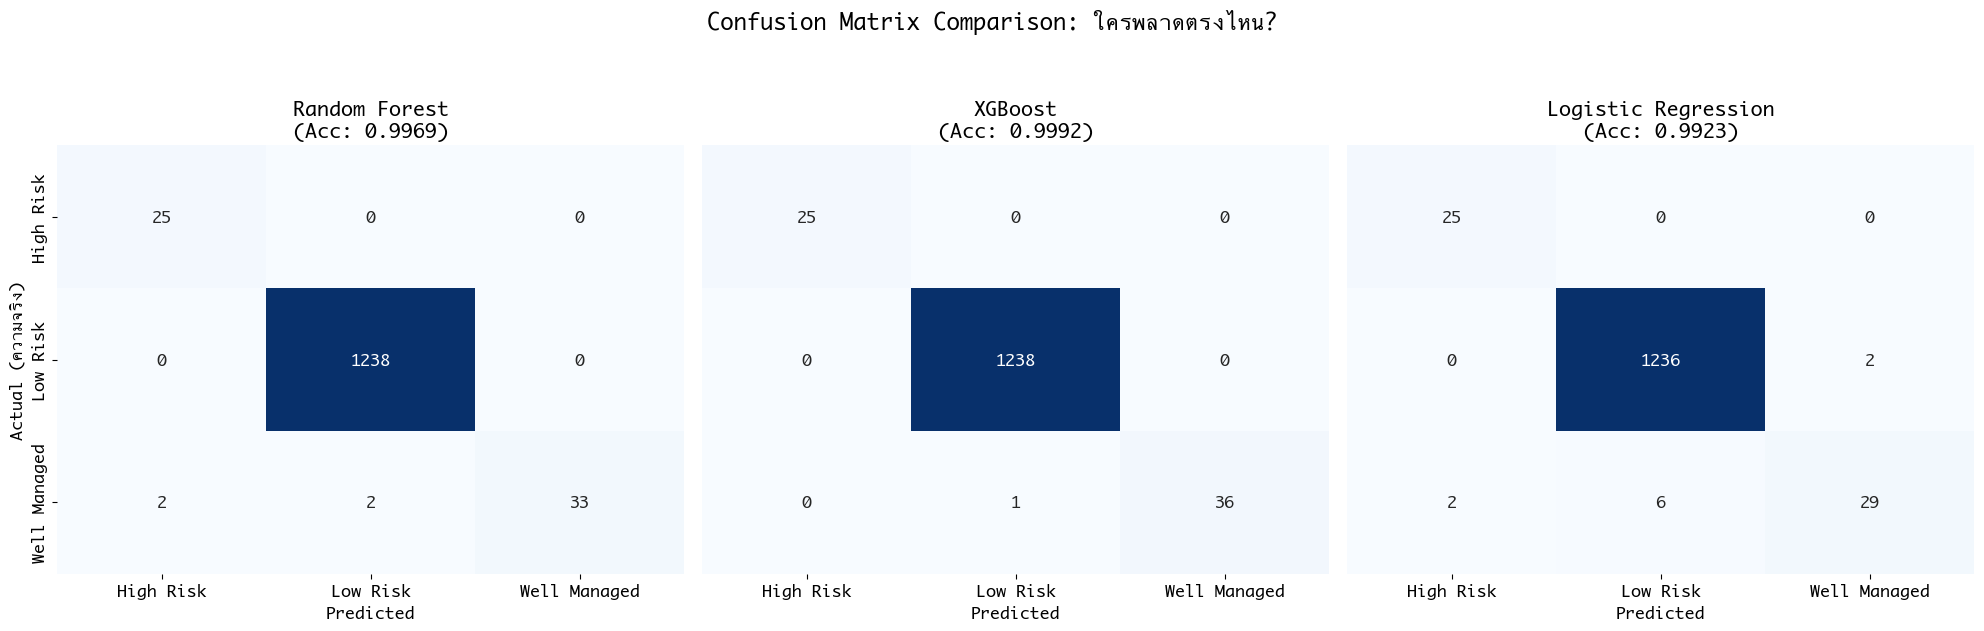

In [5]:
# สร้าง Heatmap 3 อันเรียงกัน
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
classes = le.classes_ # ['High Risk', 'Low Risk', 'Well Managed']

for i, (name, res) in enumerate(results.items()):
    cm = res["Confusion Matrix"]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=classes, yticklabels=classes, cbar=False)
    
    axes[i].set_title(f"{name}\n(Acc: {res['Accuracy']:.4f})")
    axes[i].set_xlabel('Predicted')
    if i == 0:
        axes[i].set_ylabel('Actual (ความจริง)')
    else:
        axes[i].set_yticks([]) # ซ่อนแกน Y สำหรับกราฟที่ 2,3

plt.suptitle('Confusion Matrix Comparison: ใครพลาดตรงไหน?', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()